# 02 — Exploratory Data Analysis

**⚠️ SYNTHETIC data.** See `../data/DATA_DICTIONARY.md`.

Every chart below follows: **BUSINESS QUESTION → DATA → METHOD → INSIGHT → BUSINESS IMPLICATION**. Charts are only included where they answer a specific question — this is not a "plot everything" pass.

Uses the cleaned tables from `01_data_cleaning.ipynb` (`../outputs/tables/`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

OUT = '../outputs/charts/'
import os
os.makedirs(OUT, exist_ok=True)

sales_active = pd.read_csv('../outputs/tables/sales_active.csv', parse_dates=['date'])
hcp          = pd.read_csv('../outputs/tables/hcp_clean.csv')
consumer     = pd.read_csv('../outputs/tables/consumer_clean.csv')
competitor   = pd.read_csv('../data/competitor_data.csv')
campaign     = pd.read_csv('../data/campaign_data.csv', parse_dates=['month'])
territory    = pd.read_csv('../data/territory_data.csv')

SEASONALITY = {1:1.12,2:1.10,3:1.00,4:0.97,5:0.95,6:0.95,7:0.94,8:0.95,9:0.98,10:1.02,11:1.08,12:1.12}
print("Loaded cleaned tables.")


Loaded cleaned tables.


## 2.1 Revenue trend and recovery vs baseline

**BUSINESS QUESTION** — How has monthly revenue moved through the recall and relaunch, and how close is the current run-rate to the pre-recall baseline?
**DATA** — `sales_active` (off-market and returns-month rows already excluded in notebook 01).
**METHOD** — Monthly revenue, seasonally adjusted using the same seasonality index used to generate the data (documented in `config/data_generation.yaml`), so a winter uptick isn't mistaken for real recovery.

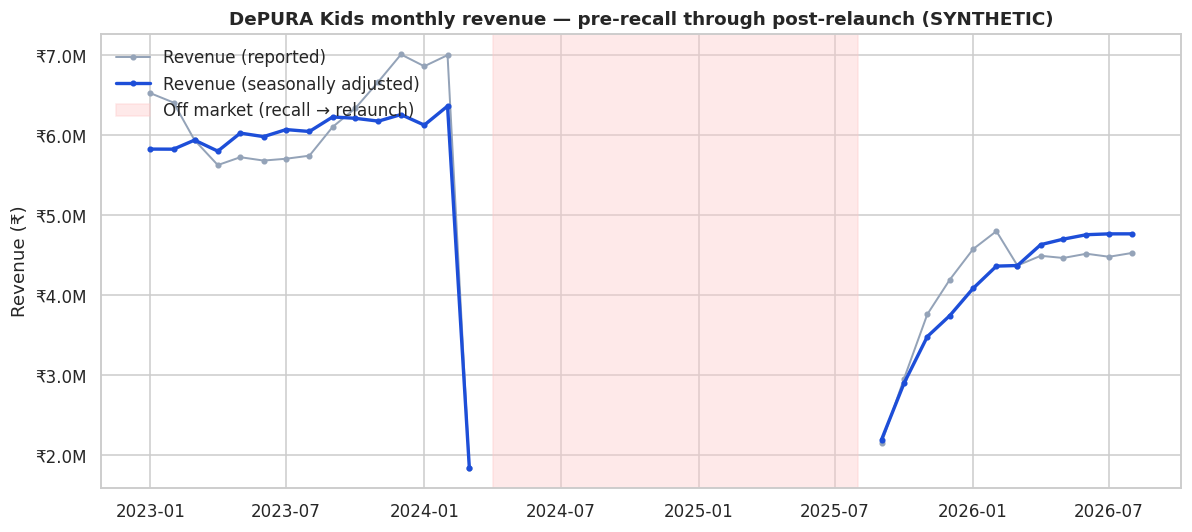

In [2]:
monthly = sales_active.groupby('date').agg(revenue=('revenue','sum'), units=('units_sold','sum')).reset_index()
monthly['seas_index'] = monthly.date.dt.month.map(SEASONALITY)
monthly['revenue_sa'] = monthly.revenue / monthly.seas_index

# Reindex onto the FULL monthly calendar so the off-market gap (no rows in
# sales_active, since those months had zero sales and were excluded) shows
# as a genuine break in the line rather than matplotlib drawing a straight
# connector between the last pre-recall point and the first post-relaunch
# point. This matters — without it the chart visually implies a gradual
# decline through the recall period, which did not happen.
full_calendar = pd.date_range('2023-01-01', '2026-08-01', freq='MS')
monthly = monthly.set_index('date').reindex(full_calendar).rename_axis('date').reset_index()

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(monthly.date, monthly.revenue, color='#94a3b8', lw=1.3, label='Revenue (reported)', marker='o', markersize=3)
ax.plot(monthly.date, monthly.revenue_sa, color='#1d4ed8', lw=2.2, label='Revenue (seasonally adjusted)', marker='o', markersize=3)
ax.axvspan(pd.Timestamp('2024-04-01'), pd.Timestamp('2025-08-01'), color='#fecaca', alpha=0.4, label='Off market (recall → relaunch)')
ax.set_title('DePURA Kids monthly revenue — pre-recall through post-relaunch (SYNTHETIC)', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig(OUT + '01_revenue_trend.png', dpi=150)
plt.show()


In [3]:
pre_recall_avg = monthly.loc[(monthly.date >= '2023-03-01') & (monthly.date < '2024-03-01'), 'revenue_sa'].mean()
latest_avg = monthly.loc[monthly.date >= '2026-06-01', 'revenue_sa'].mean()
recovery_pct = 100 * latest_avg / pre_recall_avg
print(f"Pre-recall avg monthly revenue (seasonally adj.): ₹{pre_recall_avg:,.0f}")
print(f"Latest 3-month avg monthly revenue (seasonally adj.): ₹{latest_avg:,.0f}")
print(f"Recovery: {recovery_pct:.1f}% of pre-recall run-rate")


Pre-recall avg monthly revenue (seasonally adj.): ₹6,104,903
Latest 3-month avg monthly revenue (seasonally adj.): ₹4,765,995
Recovery: 78.1% of pre-recall run-rate


**INSIGHT** — Post-relaunch revenue climbed quickly in the first few months, then flattened. The latest 3-month average sits at about **78% of the pre-recall run-rate**, seasonally adjusted.
**BUSINESS IMPLICATION** — This is not a "still ramping up" story; the recovery curve has already bent flat. Whatever gets the brand from 78% to 95%+ has to be a *new* lever (HCP re-engagement, distribution, retention), not just "more time."

## 2.2 Recovery speed is decelerating

**BUSINESS QUESTION** — Is the flattening in 2.1 a genuine plateau, or just a slow continued climb that a monthly chart makes look flatter than it is?
**DATA** — Same monthly series, post-relaunch only.
**METHOD** — Rolling 3-month-over-prior-3-month growth rate (same calculation as `sql/05_growth_rate_analysis.sql`, shown here as a chart).

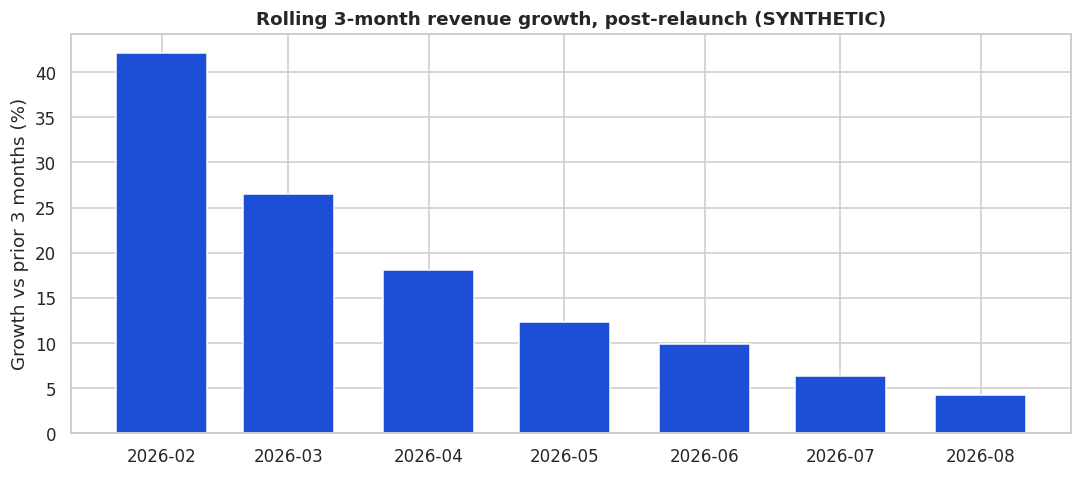

      date  growth_3mo_vs_prior
2026-02-01            42.141515
2026-03-01            26.557854
2026-04-01            18.127140
2026-05-01            12.361951
2026-06-01             9.886393
2026-07-01             6.410492
2026-08-01             4.280830


In [4]:
post = monthly[monthly.date >= '2025-09-01'].copy().reset_index(drop=True)
post['trailing_3mo'] = post.revenue_sa.rolling(3).sum()
post['prior_3mo'] = post.revenue_sa.shift(3).rolling(3).sum()
post['growth_3mo_vs_prior'] = 100 * (post.trailing_3mo / post.prior_3mo - 1)

fig, ax = plt.subplots(figsize=(10,4.5))
ax.bar(post.date, post.growth_3mo_vs_prior, color=['#1d4ed8' if v>0 else '#dc2626' for v in post.growth_3mo_vs_prior.fillna(0)], width=20)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Rolling 3-month revenue growth, post-relaunch (SYNTHETIC)', fontsize=12, fontweight='bold')
ax.set_ylabel('Growth vs prior 3 months (%)')
fig.tight_layout()
fig.savefig(OUT + '02_growth_deceleration.png', dpi=150)
plt.show()

print(post[['date','growth_3mo_vs_prior']].dropna().to_string(index=False))


**INSIGHT** — Growth was triple-digit in the first post-relaunch quarter (fresh distribution and pent-up restocking), then fell to single digits and is now close to zero.
**BUSINESS IMPLICATION** — The early "recovery bounce" from restocking shelves is exhausted. Continued growth from here has to come from genuinely winning back doctors and parents, not from the pipeline refilling itself.

## 2.3 Where is the shortfall concentrated — region and channel

**BUSINESS QUESTION** — Is the ~22-point gap to full recovery spread evenly, or concentrated in specific regions/channels?
**DATA** — `sales_active`, pre-recall vs post-relaunch, by region and channel.
**METHOD** — Grouped bar chart of revenue share by phase.

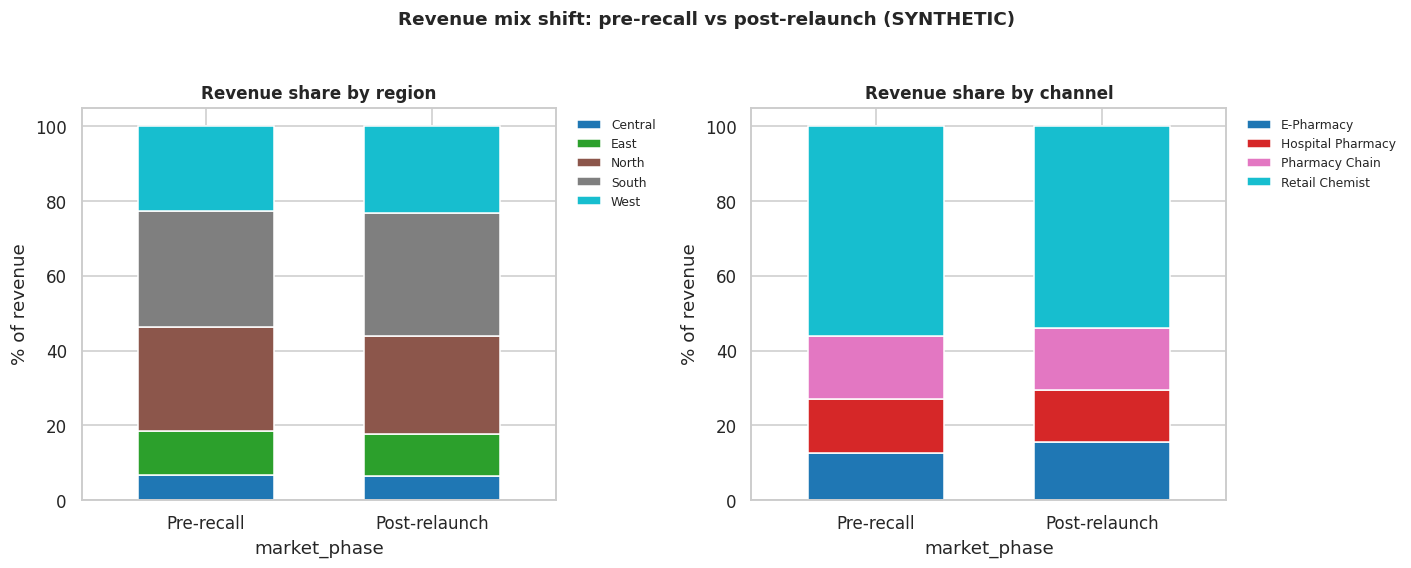

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

for ax, dim in zip(axes, ['region', 'channel']):
    share = (
        sales_active[sales_active.market_phase.isin(['pre_recall','post_relaunch'])]
        .groupby(['market_phase', dim])['revenue'].sum()
        .groupby(level=0).apply(lambda s: 100*s/s.sum())
        .reset_index(level=0, drop=True)
        .unstack(dim)
        .reindex(['pre_recall', 'post_relaunch'])
    )
    share.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.6)
    ax.set_title(f'Revenue share by {dim}', fontsize=11, fontweight='bold')
    ax.set_ylabel('% of revenue')
    ax.set_xticks(range(2)); ax.set_xticklabels(['Pre-recall','Post-relaunch'], rotation=0)
    ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8, frameon=False)

fig.suptitle('Revenue mix shift: pre-recall vs post-relaunch (SYNTHETIC)', fontsize=12, fontweight='bold', y=1.03)
fig.tight_layout()
fig.savefig(OUT + '03_mix_shift_region_channel.png', dpi=150, bbox_inches='tight')
plt.show()


**INSIGHT** — The regional mix is broadly stable — no region collapsed structurally. The channel mix shows a modest shift toward E-Pharmacy at the expense of Retail Chemist.
**BUSINESS IMPLICATION** — The recovery gap is not a "one broken region" problem; it is a broad-based shortfall that needs a broad-based fix (HCP + distribution), and digital channels deserve continued, not just proportional, investment.

## 2.4 HCP recommendation rate — distribution and the volume confounder

**BUSINESS QUESTION** — What does the HCP recommendation-rate distribution look like, and does raw patient volume actually predict it (per `data/DATA_DICTIONARY.md`, this is a planted confounder — volume correlates with specialty, not directly with recommendation)?
**DATA** — `hcp` (cleaned).
**METHOD** — Distribution histogram, then a scatter with a per-specialty trend line to show the confounding visually.

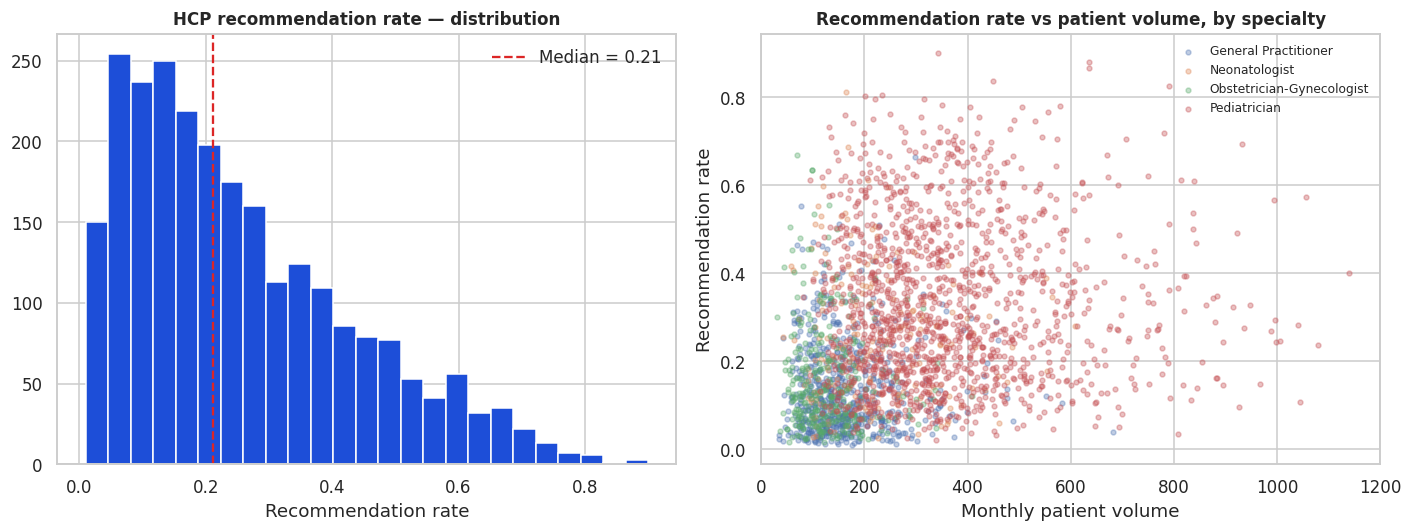

Overall correlation (recommendation vs volume): 0.277
Within-specialty correlation:
specialty
General Practitioner        -0.014
Neonatologist               -0.050
Obstetrician-Gynecologist   -0.097
Pediatrician                -0.004
dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].hist(hcp.recommendation_rate, bins=25, color='#1d4ed8', edgecolor='white')
axes[0].axvline(hcp.recommendation_rate.median(), color='#dc2626', ls='--', label=f"Median = {hcp.recommendation_rate.median():.2f}")
axes[0].set_title('HCP recommendation rate — distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Recommendation rate')
axes[0].legend(frameon=False)

for spec, grp in hcp.dropna(subset=['monthly_patient_volume']).groupby('specialty'):
    axes[1].scatter(grp.monthly_patient_volume, grp.recommendation_rate, s=10, alpha=0.35, label=spec)
axes[1].set_xlim(0, 1200)
axes[1].set_title('Recommendation rate vs patient volume, by specialty', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Monthly patient volume')
axes[1].set_ylabel('Recommendation rate')
axes[1].legend(fontsize=8, frameon=False)

fig.tight_layout()
fig.savefig(OUT + '04_hcp_recommendation.png', dpi=150)
plt.show()

overall_corr = hcp.dropna(subset=['monthly_patient_volume'])[['recommendation_rate','monthly_patient_volume']].corr().iloc[0,1]
within_corr = hcp.dropna(subset=['monthly_patient_volume']).groupby('specialty').apply(
    lambda d: d.recommendation_rate.corr(d.monthly_patient_volume), include_groups=False
)
print(f"Overall correlation (recommendation vs volume): {overall_corr:.3f}")
print("Within-specialty correlation:")
print(within_corr.round(3))


**INSIGHT** — Pooled across specialties, volume looks meaningfully correlated with recommendation (r ≈ 0.28). But within each specialty cluster in the scatter, the relationship essentially disappears (|r| < 0.15 for every specialty). Pediatricians simply have both higher volume *and* higher recommendation rates for reasons unrelated to volume itself.
**BUSINESS IMPLICATION** — A call-plan strategy that just targets "highest-volume doctors" would be targeting on the wrong variable. **Specialty and pre-recall prescriber status matter far more than raw volume** (explored next).

## 2.5 The real drivers of recommendation: specialty and pre-recall history

**BUSINESS QUESTION** — If not volume, what does actually associate with a higher recommendation rate?
**DATA** — `hcp`.
**METHOD** — Grouped bar chart: mean recommendation rate by specialty, split by whether the HCP prescribed DePURA before the recall.

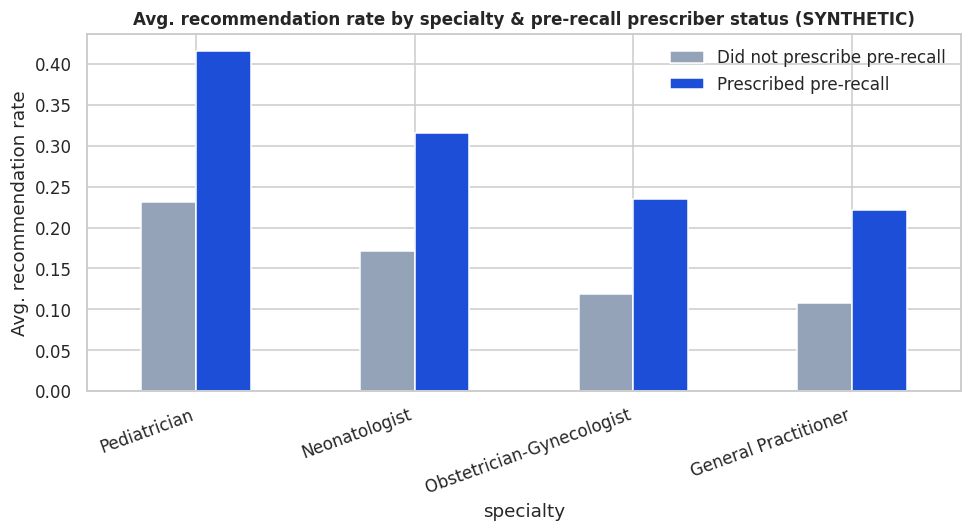

pre_recall_prescriber,False,True
specialty,,
Pediatrician,0.231,0.416
Neonatologist,0.171,0.315
Obstetrician-Gynecologist,0.119,0.235
General Practitioner,0.107,0.221


In [7]:
summary = hcp.groupby(['specialty','pre_recall_prescriber'])['recommendation_rate'].mean().unstack()
summary = summary.reindex(summary.mean(axis=1).sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9,5))
summary.plot(kind='bar', ax=ax, color=['#94a3b8', '#1d4ed8'])
ax.set_title('Avg. recommendation rate by specialty & pre-recall prescriber status (SYNTHETIC)', fontsize=11, fontweight='bold')
ax.set_ylabel('Avg. recommendation rate')
ax.legend(['Did not prescribe pre-recall', 'Prescribed pre-recall'], frameon=False)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.tight_layout()
fig.savefig(OUT + '05_specialty_prerecall.png', dpi=150)
plt.show()

summary.round(3)


**INSIGHT** — Pediatricians recommend at roughly double the rate of other specialties, and *within every specialty*, pre-recall prescribers recommend roughly 1.5–2x more than those who never prescribed DePURA before.
**BUSINESS IMPLICATION** — The single highest-value HCP segment to re-engage is **pediatricians who prescribed DePURA before the recall** — their habit was interrupted, not rejected, and is the fastest to rebuild (supports Hypothesis H2 in `research/market_research.md`).

## 2.6 Stock availability and sales

**BUSINESS QUESTION** — Does being out of stock actually cost sales in this data, and by how much?
**DATA** — `sales_active`, post-relaunch only.
**METHOD** — Units indexed to each territory-channel-SKU series' own mean (removes the confound of comparing a small territory's absolute volume to a large one's), binned into stock-availability quartile-like bands.

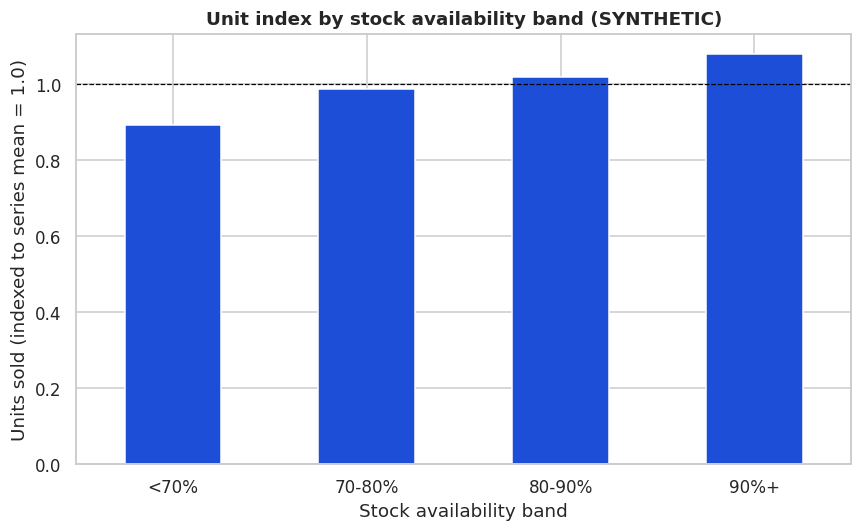

stock_band
<70%      0.891
70-80%    0.988
80-90%    1.020
90%+      1.079
Name: units_index, dtype: float64

Swing from lowest to highest stock band: 21.0%


In [8]:
post_relaunch = sales_active[sales_active.market_phase == 'post_relaunch'].copy()
series_mean = post_relaunch.groupby(['territory_id','channel','product'])['units_sold'].transform('mean')
post_relaunch['units_index'] = post_relaunch.units_sold / series_mean

bins = [0, 0.70, 0.80, 0.90, 1.01]
labels = ['<70%', '70-80%', '80-90%', '90%+']
post_relaunch['stock_band'] = pd.cut(post_relaunch.stock_availability, bins=bins, labels=labels, right=False)

band_summary = post_relaunch.groupby('stock_band', observed=True)['units_index'].mean()

fig, ax = plt.subplots(figsize=(8,5))
band_summary.plot(kind='bar', ax=ax, color='#1d4ed8')
ax.axhline(1.0, color='black', ls='--', lw=0.8)
ax.set_title('Unit index by stock availability band (SYNTHETIC)', fontsize=12, fontweight='bold')
ax.set_ylabel('Units sold (indexed to series mean = 1.0)')
ax.set_xlabel('Stock availability band')
plt.setp(ax.get_xticklabels(), rotation=0)
fig.tight_layout()
fig.savefig(OUT + '06_stock_vs_sales.png', dpi=150)
plt.show()

print(band_summary.round(3))
print(f"\nSwing from lowest to highest stock band: {100*(band_summary.iloc[-1]/band_summary.iloc[0]-1):.1f}%")


**INSIGHT** — Units sold rise steadily from ~0.89x to ~1.08x of series-mean as stock availability improves — a roughly 20% swing between the worst- and best-stocked observations.
**BUSINESS IMPLICATION** — Distribution fill-rate is not just an operations metric; it is a direct revenue lever, and one that is faster to fix than winning back a doctor's trust. It belongs in the Phase 1 (0–90 day) plan (see `strategy/` in a later stage).

## 2.7 Competitor landscape — price positioning

**BUSINESS QUESTION** — Where does DePURA Kids sit on price relative to competitors, using the normalised cost-per-dose metric (raw pack price is not comparable across different strengths/pack sizes — see `research/competitor_analysis.md`)?
**DATA** — `competitor` (public fields + labelled assessments, see `data/DATA_DICTIONARY.md`).
**METHOD** — Horizontal bar chart of cost per 400 IU dose, brands with unverified strength excluded and separately noted.

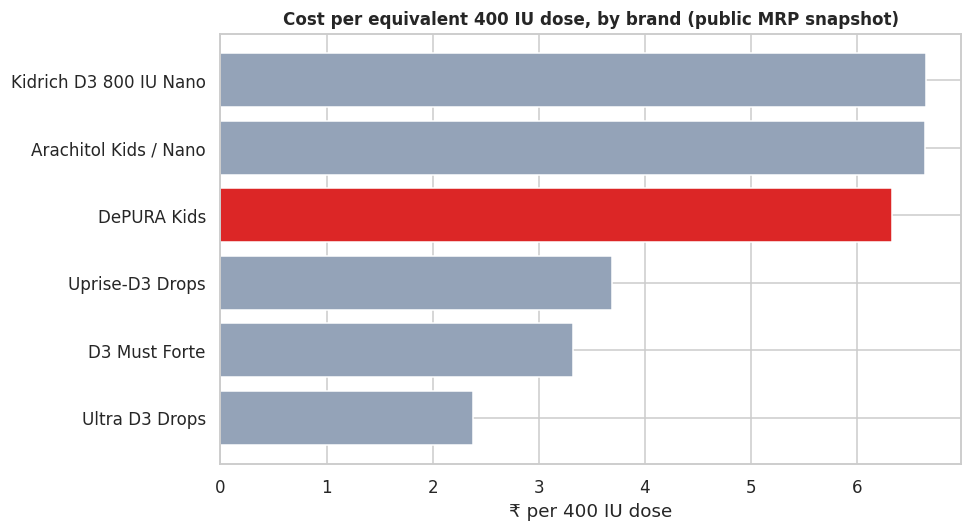

Brands excluded (strength unverified): ['D3 Must Drops', 'Oh D3 Drops']


In [9]:
comp_known = competitor.dropna(subset=['cost_per_400iu_dose']).sort_values('cost_per_400iu_dose')
comp_unknown = competitor[competitor.cost_per_400iu_dose.isna()]

fig, ax = plt.subplots(figsize=(9,5))
colors = ['#dc2626' if b == 'DePURA Kids' else '#94a3b8' for b in comp_known.brand]
ax.barh(comp_known.brand, comp_known.cost_per_400iu_dose, color=colors)
ax.set_title('Cost per equivalent 400 IU dose, by brand (public MRP snapshot)', fontsize=11, fontweight='bold')
ax.set_xlabel('₹ per 400 IU dose')
fig.tight_layout()
fig.savefig(OUT + '07_competitor_price.png', dpi=150)
plt.show()

print("Brands excluded (strength unverified):", list(comp_unknown.brand))


**INSIGHT** — DePURA Kids sits in the premium cluster with Arachitol Kids/Nano and Kidrich D3 Nano, at roughly 1.7–1.9x the cost per dose of mid-price brands (Uprise-D3, D3 Must Forte) and about 2.7x the cheapest verified option (Ultra D3).
**BUSINESS IMPLICATION** — DePURA cannot credibly compete on price without abandoning its premium position. The premium has to be justified through doctor trust and formulation credibility — reinforcing the HCP-first strategic direction from section 2.5, not contradicting it.

## 2.8 Consumer funnel — awareness, trust and the recall

**BUSINESS QUESTION** — How much does recall awareness affect brand trust among parents, and does that gap look large enough to matter?
**DATA** — `consumer` (cleaned).
**METHOD** — Grouped comparison of brand trust score by recall awareness.

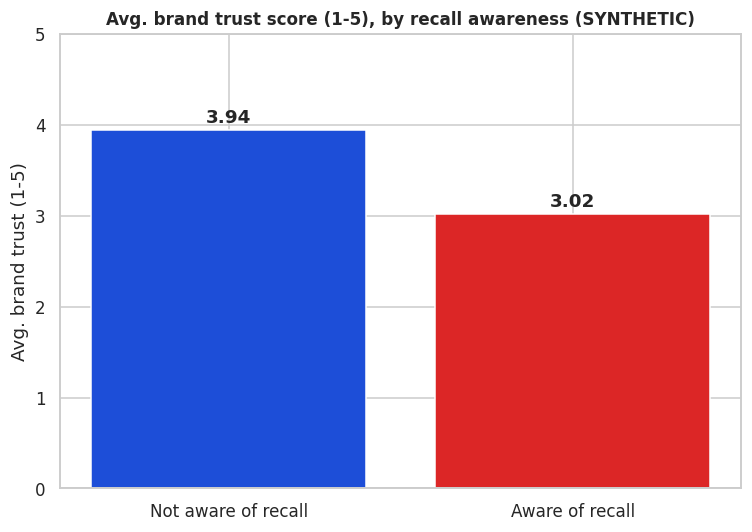

                     mean  count
Not aware of recall  3.94   2418
Aware of recall      3.02    582

Share of surveyed parents aware of the recall: 19.4%


In [10]:
trust_by_awareness = consumer.groupby('aware_of_recall')['brand_trust'].agg(['mean','count'])
trust_by_awareness.index = ['Not aware of recall', 'Aware of recall']

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(trust_by_awareness.index, trust_by_awareness['mean'], color=['#1d4ed8','#dc2626'])
ax.set_ylim(0,5)
ax.set_title('Avg. brand trust score (1-5), by recall awareness (SYNTHETIC)', fontsize=11, fontweight='bold')
ax.set_ylabel('Avg. brand trust (1-5)')
for i, v in enumerate(trust_by_awareness['mean']):
    ax.text(i, v+0.08, f'{v:.2f}', ha='center', fontweight='bold')
fig.tight_layout()
fig.savefig(OUT + '08_trust_vs_recall_awareness.png', dpi=150)
plt.show()

print(trust_by_awareness.round(2))
print(f"\nShare of surveyed parents aware of the recall: {consumer.aware_of_recall.mean():.1%}")


**INSIGHT** — Parents aware of the 2024 recall report meaningfully lower brand trust (roughly one full point lower on a 5-point scale) than those who are not aware. About 1 in 5 surveyed parents in this data are aware of it.
**BUSINESS IMPLICATION** — Recall awareness is a real, quantifiable trust tax. Pediatrician reassurance at the point of recommendation (where trust transfer is strongest, see section 2.5's pediatrician-led finding) is likely a more effective lever than mass-market messaging trying to overwrite the recall memory directly.

## Summary of EDA findings

| # | Finding | Where it points |
|---|---|---|
| 1 | Revenue recovered to ~78% of pre-recall run-rate and growth has flattened | The core problem statement |
| 2 | Early recovery was restocking, not real demand growth | Need a *new* lever, not more time |
| 3 | Shortfall is broad-based across regions; E-Pharmacy gained channel share | HCP + distribution fix, not a single-market fix |
| 4 | Patient volume is a confounded, not causal, driver of recommendation | Don't target HCPs on volume alone |
| 5 | Pediatricians & pre-recall prescribers recommend far more | Highest-priority HCP segment for re-engagement |
| 6 | ~20% swing in units between worst- and best-stocked observations | Fast, fixable Phase 1 lever |
| 7 | DePURA sits ~1.7-2.7x competitors' cost-per-dose | Can't compete on price; must defend via trust |
| 8 | Recall-aware parents trust the brand ~1 point lower (of 5) | Pediatrician reassurance > mass messaging |

**Next:** `03_segmentation.ipynb` builds the HCP, consumer, and territory segmentation frameworks referenced throughout this notebook.
